# HarmonyOS usability themes from the human-validated posts

Re-derives the HarmonyOS positive and negative themes from the 302 posts that both authors confirmed as genuine
opinions about HarmonyOS's AI features (the set behind the HarmonyOS estimate in Table 2), instead of the 394 posts
retained by the verification pass. The clustering code is identical to the pipeline notebook
(`Apple_HarmonyOS_Usability_v4.ipynb`, Section 7): all-mpnet-base-v2 embeddings, a k-means sweep with the
silhouette-best k, and average-linkage merging of redundant clusters at distance 0.45.

Data are read directly from the archived release (v1.0.0, DOI 10.5281/zenodo.23098900). No API keys are needed.
Results are saved to Google Drive (`OUT_DIR`, Section 0) when run in Colab, or to a local `outputs/` folder otherwise.
A GPU runtime is optional. Figures are saved at 300 dpi.

In [1]:
!pip install -q sentence-transformers

## 0. Output location
In Colab, Google Drive is mounted and all results are written to `OUT_DIR`, the folder that holds the other Apple/HarmonyOS usability outputs. Outside Colab, results go to a local `outputs/` folder.

In [2]:
import os
SAVE_TO_DRIVE = True
OUT_DIR = "/content/drive/My Drive/OS_Trends_NFR/UsbilityData/forum_collection_output"
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if SAVE_TO_DRIVE and IN_COLAB:
    drive.mount("/content/drive")
else:
    OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)
CSV_PATH = f"{OUT_DIR}/harmonyos_themes_validated.csv"
FIG_PATH = f"{OUT_DIR}/harmonyos_validated_dendrogram.png"
SUMMARY_PATH = f"{OUT_DIR}/harmonyos_themes_validated_summary.json"
print("Results will be saved to:", OUT_DIR)

Mounted at /content/drive
Results will be saved to: /content/drive/My Drive/OS_Trends_NFR/UsbilityData/forum_collection_output


In [3]:
import numpy as np, pandas as pd, torch, json
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

REL = "https://raw.githubusercontent.com/malhawarat/OS_Trends_NFR/v1.0.0/03_Usability/Apple_HarmonyOS_Analysis"
idx = pd.read_csv(f"{REL}/data/posts_index_v4.csv")
allp = pd.read_csv(f"{REL}/data/extracted_aspect_sentiment_v4_all.csv")
confirmed = idx[(idx.platform == "harmonyos") & idx.analyzed_final]
extracted_df = allp[(allp.platform == "harmonyos") & allp.url.isin(confirmed.url)].copy()
print(f"confirmed HarmonyOS posts: {confirmed.url.nunique()} | aspect pairs: {len(extracted_df)}")
print(extracted_df.sentiment.value_counts().to_dict())

device: cuda
confirmed HarmonyOS posts: 302 | aspect pairs: 396
{'negative': 208, 'positive': 169, 'neutral': 19}


## Clustering (code identical to the pipeline notebook, Section 7)

In [4]:
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2', device=device)

def run_kmeans_sweep(embeddings, k_range, random_state=42):
    rows = []
    for k in k_range:
        if k >= len(embeddings):
            break
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(embeddings)
        sil = silhouette_score(embeddings, labels)
        db = davies_bouldin_score(embeddings, labels)
        ch = calinski_harabasz_score(embeddings, labels)
        rows.append({'k': k, 'silhouette': sil, 'davies_bouldin': db,
                      'calinski_harabasz': ch, 'inertia': km.inertia_})
        print(f"k={k:2d}  silhouette={sil:.4f}  davies_bouldin={db:.4f}")
    return pd.DataFrame(rows)

def compute_centroids(embeddings, labels, k):
    return np.array([embeddings[labels == c].mean(axis=0) for c in range(k)])

def agglomerative_merge(sim_matrix, distance_threshold, method='average'):
    n = sim_matrix.shape[0]
    if n < 2:
        return [[0]] if n == 1 else [], None
    dist_matrix = 1 - sim_matrix
    np.fill_diagonal(dist_matrix, 0)
    dist_matrix = (dist_matrix + dist_matrix.T) / 2
    condensed = squareform(dist_matrix, checks=False)
    Z = linkage(condensed, method=method)
    labels = fcluster(Z, t=distance_threshold, criterion='distance')
    groups = {}
    for i, lab in enumerate(labels):
        groups.setdefault(lab, []).append(i)
    return list(groups.values()), Z

def summarize_clusters(phrases, labels, k, n_samples=10, n_top_terms=8):
    summary = []
    for c in range(k):
        idx = np.where(labels == c)[0]
        cluster_phrases = [phrases[i] for i in idx]
        size = len(cluster_phrases)
        try:
            vec = CountVectorizer(ngram_range=(1,2), stop_words='english', max_features=50)
            X = vec.fit_transform(cluster_phrases)
            term_counts = np.asarray(X.sum(axis=0)).flatten()
            terms = vec.get_feature_names_out()
            top_terms = [t for t,_ in sorted(zip(terms, term_counts), key=lambda x: -x[1])[:n_top_terms]]
        except ValueError:
            top_terms = []
        samples = list(np.random.RandomState(42).choice(cluster_phrases, min(n_samples, size), replace=False))
        summary.append({'cluster': c, 'size': size, 'pct_of_total': round(100*size/len(phrases), 2),
                         'top_terms': ', '.join(top_terms), 'sample_phrases': samples})
    return pd.DataFrame(summary).sort_values('size', ascending=False).reset_index(drop=True)

def summarize_merged(phrases, labels, merge_groups, n_samples=10, n_top_terms=8):
    summary = []
    for meta_id, group in enumerate(merge_groups):
        idx = np.concatenate([np.where(labels == c)[0] for c in group])
        cluster_phrases = [phrases[i] for i in idx]
        size = len(cluster_phrases)
        try:
            vec = CountVectorizer(ngram_range=(1,2), stop_words='english', max_features=50)
            X = vec.fit_transform(cluster_phrases)
            term_counts = np.asarray(X.sum(axis=0)).flatten()
            terms = vec.get_feature_names_out()
            top_terms = [t for t,_ in sorted(zip(terms, term_counts), key=lambda x: -x[1])[:n_top_terms]]
        except ValueError:
            top_terms = []
        samples = list(np.random.RandomState(42).choice(cluster_phrases, min(n_samples, size), replace=False))
        summary.append({'meta_cluster': meta_id, 'original_clusters': group, 'size': size,
                         'pct_of_total': round(100*size/len(phrases), 2),
                         'top_terms': ', '.join(top_terms), 'sample_phrases': samples})
    return pd.DataFrame(summary).sort_values('size', ascending=False).reset_index(drop=True)

DISTANCE_THRESHOLD = 0.45
LINKAGE_METHOD = 'average'

def cluster_platform(platform_name, extracted_df, distance_threshold=DISTANCE_THRESHOLD):
    sub = extracted_df[extracted_df['platform'] == platform_name].copy()
    sub['summary_clean'] = sub['summary'].str.strip().str.lower()
    results = {}
    for sentiment in ['positive', 'negative']:
        phrases = sub.loc[sub['sentiment']==sentiment, 'summary_clean'].tolist()
        if len(phrases) < 4:
            print(f"{platform_name}/{sentiment}: only {len(phrases)} phrases -- too few to cluster meaningfully.")
            results[sentiment] = None
            continue
        print(f"\n=== Clustering {platform_name}/{sentiment} ({len(phrases)} phrases) ===")
        embeddings = model.encode(phrases, show_progress_bar=True)
        max_k = max(2, min(30, len(phrases) // 10, len(phrases) - 1))
        sweep = run_kmeans_sweep(embeddings, range(2, max_k + 1))
        if len(sweep) == 0:
            results[sentiment] = None
            continue
        best_k = int(sweep.loc[sweep['silhouette'].idxmax(), 'k'])
        print(f"Silhouette-best k for {platform_name}/{sentiment}: {best_k}")
        km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
        labels = km.fit_predict(embeddings)
        raw_summary = summarize_clusters(phrases, labels, best_k)

        centroids = compute_centroids(embeddings, labels, best_k)
        sim_matrix = cosine_similarity(centroids)
        merge_groups, Z = agglomerative_merge(sim_matrix, distance_threshold, LINKAGE_METHOD)
        merged_summary = summarize_merged(phrases, labels, merge_groups)
        print(f"  {best_k} raw clusters -> {len(merge_groups)} merged meta-themes "
              f"(distance_threshold={distance_threshold})")

        results[sentiment] = {
            'sweep': sweep, 'best_k': best_k, 'raw_summary': raw_summary,
            'sim_matrix': sim_matrix, 'merge_groups': merge_groups, 'Z': Z,
            'merged_summary': merged_summary, 'phrases': phrases, 'labels': labels,
        }
    return results


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
harmonyos_results = cluster_platform('harmonyos', extracted_df)


=== Clustering harmonyos/positive (169 phrases) ===


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

k= 2  silhouette=0.1044  davies_bouldin=3.1990
k= 3  silhouette=0.0724  davies_bouldin=2.8278
k= 4  silhouette=0.0882  davies_bouldin=2.4257
k= 5  silhouette=0.0962  davies_bouldin=2.6460
k= 6  silhouette=0.1106  davies_bouldin=2.2997
k= 7  silhouette=0.1127  davies_bouldin=2.5927
k= 8  silhouette=0.1255  davies_bouldin=2.5632
k= 9  silhouette=0.1224  davies_bouldin=2.4427
k=10  silhouette=0.1218  davies_bouldin=2.3557
k=11  silhouette=0.1262  davies_bouldin=2.1891
k=12  silhouette=0.1422  davies_bouldin=2.2351
k=13  silhouette=0.1493  davies_bouldin=2.1187
k=14  silhouette=0.1033  davies_bouldin=2.4758
k=15  silhouette=0.1515  davies_bouldin=2.0413
k=16  silhouette=0.1297  davies_bouldin=1.9858
Silhouette-best k for harmonyos/positive: 15
  15 raw clusters -> 12 merged meta-themes (distance_threshold=0.45)

=== Clustering harmonyos/negative (208 phrases) ===


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

k= 2  silhouette=0.1116  davies_bouldin=3.0060
k= 3  silhouette=0.1348  davies_bouldin=2.5481
k= 4  silhouette=0.0972  davies_bouldin=2.4397
k= 5  silhouette=0.1080  davies_bouldin=2.4982
k= 6  silhouette=0.0962  davies_bouldin=2.5434
k= 7  silhouette=0.0967  davies_bouldin=2.7162
k= 8  silhouette=0.1041  davies_bouldin=2.6804
k= 9  silhouette=0.1153  davies_bouldin=2.3642
k=10  silhouette=0.1143  davies_bouldin=2.6481
k=11  silhouette=0.1184  davies_bouldin=2.4832
k=12  silhouette=0.1076  davies_bouldin=2.5106
k=13  silhouette=0.1163  davies_bouldin=2.5301
k=14  silhouette=0.1098  davies_bouldin=2.4446
k=15  silhouette=0.1189  davies_bouldin=2.3227
k=16  silhouette=0.1185  davies_bouldin=2.3894
k=17  silhouette=0.1260  davies_bouldin=2.3857
k=18  silhouette=0.1195  davies_bouldin=2.2770
k=19  silhouette=0.1144  davies_bouldin=2.2057
k=20  silhouette=0.1287  davies_bouldin=2.1659
Silhouette-best k for harmonyos/negative: 3
  3 raw clusters -> 3 merged meta-themes (distance_threshold=0.

## Themes

In [6]:
rows = []
for sentiment in ["positive", "negative"]:
    r = harmonyos_results.get(sentiment)
    if r is None:
        continue
    n = len(r["phrases"])
    print(f"\n==== HarmonyOS {sentiment}: {n} phrases, k = {r['best_k']} -> {len(r['merge_groups'])} merged themes ====")
    for _, t in r["merged_summary"].iterrows():
        samples = [str(x) for x in t["sample_phrases"]][:8]
        print(f"{t['pct_of_total']:5.1f}%  n={t['size']:3d} | {t['top_terms']}")
        print(f"         e.g. {samples}")
        rows.append({"sentiment": sentiment, "meta_cluster": t["meta_cluster"], "size": t["size"],
                     "pct_of_total": t["pct_of_total"], "top_terms": t["top_terms"],
                     "sample_phrases": "; ".join(samples)})
themes = pd.DataFrame(rows)
themes.to_csv(CSV_PATH, index=False)
print(f"\nSaved {CSV_PATH}")


==== HarmonyOS positive: 169 phrases, k = 15 -> 12 merged themes ====
 53.2%  n= 90 | ai, features, feature, ai features, pose, camera, photo, ai photo
         e.g. ['helpful ai feature', 'visual search', 'ai animation smoothness', 'system-level ai', 'ai photo editing', 'pose variation tool', 'ai idea', 'ai integration']
  7.7%  n= 13 | overall, innovation, clearer, clearer picture, clutter, clutter expressions, daily, daily usability
         e.g. ['innovation', 'overall praise', 'overall improvement', 'photo quality', 'clearer picture', 'original innovation', 'less oversharpening', 'makes life easier']
  5.9%  n= 10 | ai, zoom, ai ultra, clarity, ultra, ultra clarity, clarity zoom, ai zoom
         e.g. ['ai ultra clarity zoom', 'ai ultra clarity zoom', 'ai ultra clarity zoom', 'ai ultra clarity zoom', 'ai ultra clarity zoom', 'ai zoom quality', 'ai ultra clarity zoom', 'ai zoom enhancement']
  5.9%  n= 10 | feature, tech, changing, changing feature, concept, desire, desire feature

## Merge diagnostics (300 dpi)

Saved /content/drive/My Drive/OS_Trends_NFR/UsbilityData/forum_collection_output/harmonyos_validated_dendrogram.png (300 dpi)


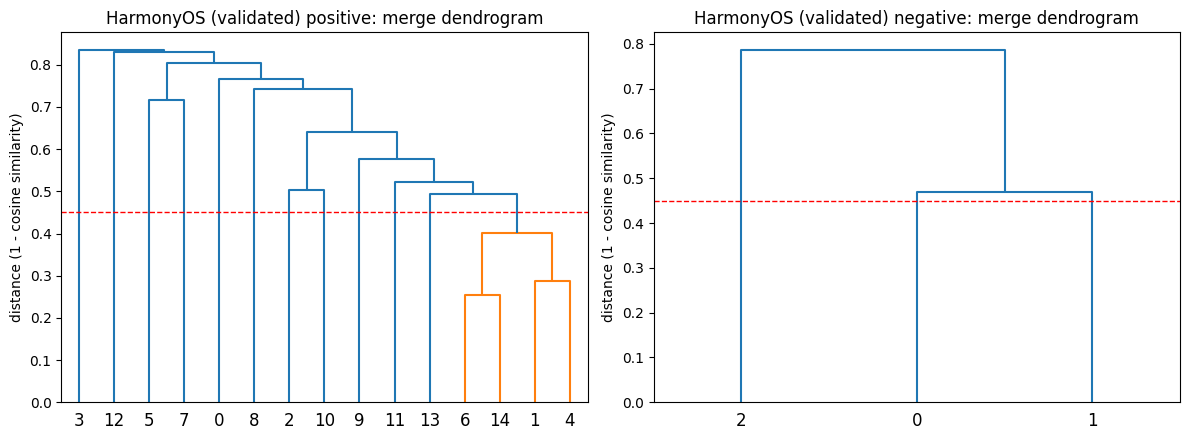

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, sentiment in zip(axes, ["positive", "negative"]):
    r = harmonyos_results.get(sentiment)
    if r is None or r["Z"] is None:
        ax.set_visible(False); continue
    dendrogram(r["Z"], ax=ax, color_threshold=DISTANCE_THRESHOLD)
    ax.axhline(DISTANCE_THRESHOLD, color="red", ls="--", lw=1)
    ax.set_title(f"HarmonyOS (validated) {sentiment}: merge dendrogram")
    ax.set_ylabel("distance (1 - cosine similarity)")
plt.tight_layout(); plt.savefig(FIG_PATH, dpi=300); print(f"Saved {FIG_PATH} (300 dpi)"); plt.show()

## Run summary
Writes a short summary file next to the theme table and lists everything saved in this run.

In [8]:
summary = {"source": "v1.0.0 release, DOI 10.5281/zenodo.23098900",
           "confirmed_posts": int(confirmed.url.nunique()), "aspect_pairs": int(len(extracted_df)),
           "sentiment_counts": {k: int(v) for k, v in extracted_df.sentiment.value_counts().items()},
           "clustering": {s: {"phrases": len(harmonyos_results[s]["phrases"]), "k": int(harmonyos_results[s]["best_k"]),
                              "merged_themes": len(harmonyos_results[s]["merge_groups"])}
                          for s in ["positive", "negative"] if harmonyos_results.get(s) is not None},
           "distance_threshold": DISTANCE_THRESHOLD}
with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=1)
print(json.dumps(summary, indent=1))
for p in [CSV_PATH, FIG_PATH, SUMMARY_PATH]:
    print(("saved   " if os.path.exists(p) else "MISSING ") + p)

{
 "source": "v1.0.0 release, DOI 10.5281/zenodo.23098900",
 "confirmed_posts": 302,
 "aspect_pairs": 396,
 "sentiment_counts": {
  "negative": 208,
  "positive": 169,
  "neutral": 19
 },
 "clustering": {
  "positive": {
   "phrases": 169,
   "k": 15,
   "merged_themes": 12
  },
  "negative": {
   "phrases": 208,
   "k": 3,
   "merged_themes": 3
  }
 },
 "distance_threshold": 0.45
}
saved   /content/drive/My Drive/OS_Trends_NFR/UsbilityData/forum_collection_output/harmonyos_themes_validated.csv
saved   /content/drive/My Drive/OS_Trends_NFR/UsbilityData/forum_collection_output/harmonyos_validated_dendrogram.png
saved   /content/drive/My Drive/OS_Trends_NFR/UsbilityData/forum_collection_output/harmonyos_themes_validated_summary.json
